In [92]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [93]:
ticker_symbol = "SPY"
ticker = yf.Ticker(ticker_symbol)


In [94]:
history = ticker.history(period="5d")

spot_price = history["Close"].iloc[-1]

print("Current SPY price:", spot_price)
print(pd.DataFrame(history))

Current SPY price: 756.0800170898438
                                 Open        High         Low       Close  \
Date                                                                        
2026-06-09 00:00:00-04:00  743.630005  746.900024  722.590027  737.049988   
2026-06-10 00:00:00-04:00  733.390015  738.380005  725.330017  725.429993   
2026-06-11 00:00:00-04:00  728.760010  740.000000  724.409973  737.760010   
2026-06-12 00:00:00-04:00  740.710022  744.440002  735.030029  741.750000   
2026-06-15 00:00:00-04:00  751.849976  756.669983  751.760010  756.080017   

                             Volume  Dividends  Stock Splits  Capital Gains  
Date                                                                         
2026-06-09 00:00:00-04:00  87683500        0.0           0.0            0.0  
2026-06-10 00:00:00-04:00  60341300        0.0           0.0            0.0  
2026-06-11 00:00:00-04:00  86330500        0.0           0.0            0.0  
2026-06-12 00:00:00-04:00  569398

In [95]:
expirations = ticker.options

print(expirations)

('2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-30', '2026-07-02', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [96]:
expiration = expirations[12]

print("Selected expiration:", expiration)

Selected expiration: 2026-07-17


In [97]:
option_chain = ticker.option_chain(expiration)

calls = option_chain.calls

puts = option_chain.puts

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260717C00360000,2026-06-05 15:45:22+00:00,360.0,387.81,394.47,397.29,0.0,0.0,1.0,50,1.180912,True,REGULAR,USD
1,SPY260717C00365000,2026-05-28 14:12:58+00:00,365.0,388.54,389.37,392.17,0.0,0.0,1.0,31,1.143315,True,REGULAR,USD
2,SPY260717C00370000,2026-05-01 16:21:26+00:00,370.0,355.11,368.15,370.93,0.0,0.0,10.0,1,0.000010,True,REGULAR,USD
3,SPY260717C00375000,2026-05-06 15:33:13+00:00,375.0,358.95,363.16,365.94,0.0,0.0,13.0,5,0.000010,True,REGULAR,USD
4,SPY260717C00380000,2026-05-21 15:07:20+00:00,380.0,358.86,374.32,377.15,0.0,0.0,NaN,10,1.082768,True,REGULAR,USD


In [98]:
calls = calls[
   [
       "strike",
        "bid",
        "ask",
        "lastPrice",
        "volume",
        "openInterest",
        "impliedVolatility"
    ]

].copy()

calls.head()

,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility
0,360.0,394.47,397.29,387.81,1.0,50,1.180912
1,365.0,389.37,392.17,388.54,1.0,31,1.143315
2,370.0,368.15,370.93,355.11,10.0,1,0.000010
3,375.0,363.16,365.94,358.95,13.0,5,0.000010
4,380.0,374.32,377.15,358.86,NaN,10,1.082768


In [99]:
calls["mid_price"] = (calls["bid"] + calls["ask"]) / 2
calls[["strike", "bid", "ask", "mid_price"]].head(10)

,strike,bid,ask,mid_price
0,360.0,394.47,397.29,395.880
1,365.0,389.37,392.17,390.770
2,370.0,368.15,370.93,369.540
3,375.0,363.16,365.94,364.550
4,380.0,374.32,377.15,375.735
5,385.0,369.48,372.31,370.895
6,395.0,359.40,362.22,360.810
7,400.0,354.47,357.29,355.880
8,405.0,349.35,352.16,350.755
9,410.0,328.09,330.90,329.495


In [100]:
calls = calls[ (calls["bid"] > 0) & (calls["ask"] > calls["bid"])].copy()

calls["relative_spread"] = (calls["ask"] - calls["bid"]) / calls["mid_price"]

calls = calls[calls["relative_spread"] < 0.30].copy()

calls = calls[calls["openInterest"] > 0].copy()

calls.head()

,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility,mid_price,relative_spread
0,360.0,394.47,397.29,387.81,1.0,50,1.180912,395.880,0.007123
1,365.0,389.37,392.17,388.54,1.0,31,1.143315,390.770,0.007165
2,370.0,368.15,370.93,355.11,10.0,1,0.000010,369.540,0.007523
3,375.0,363.16,365.94,358.95,13.0,5,0.000010,364.550,0.007626
4,380.0,374.32,377.15,358.86,NaN,10,1.082768,375.735,0.007532


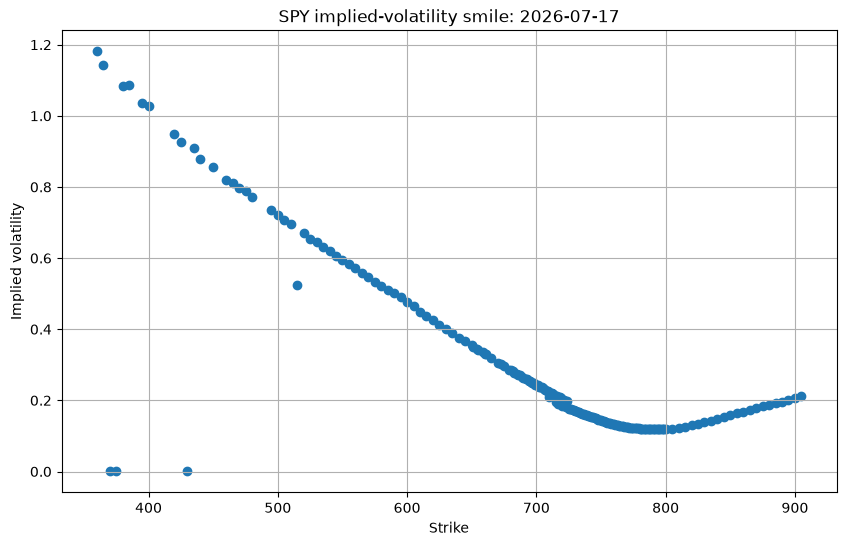

In [101]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls["strike"],
    calls["impliedVolatility"]
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(f"SPY implied-volatility smile: {expiration}")
plt.grid()

plt.show()

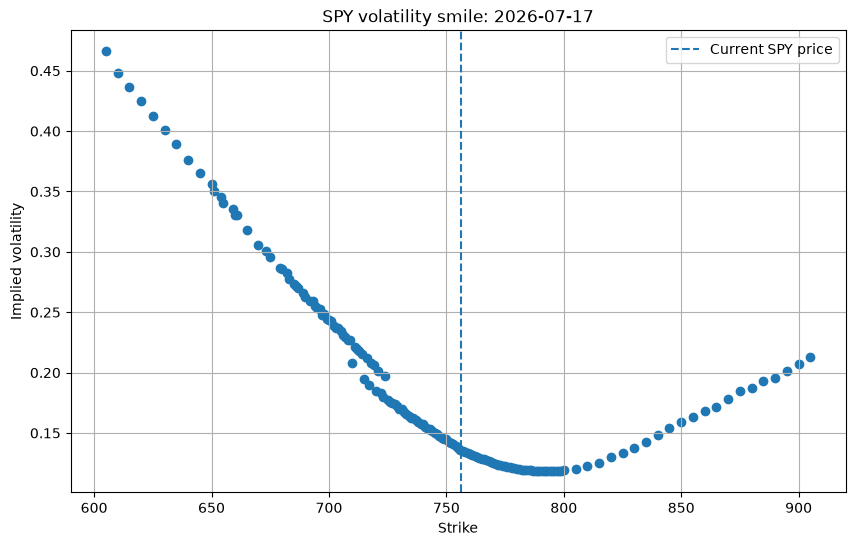

In [102]:
lower_strike = 0.8 * spot_price
upper_strike = 1.2 * spot_price

calls_near_money = calls[
    calls["strike"].between(
        lower_strike,
        upper_strike
    )
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    calls_near_money["strike"],
    calls_near_money["impliedVolatility"]
)

plt.axvline(
    spot_price,
    linestyle="--",
    label="Current SPY price"
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(f"SPY volatility smile: {expiration}")
plt.legend()
plt.grid()

plt.show()

In [103]:
today = pd.Timestamp.now().normalize()
expiration_date = pd.Timestamp(expiration)

days_to_expiration = (expiration_date - today).days

T = days_to_expiration / 365

print("Days to expiration:", days_to_expiration)
print("Time to maturity:", T)

Days to expiration: 32
Time to maturity: 0.08767123287671233


In [104]:
forward_price = spot_price
calls_near_money["log_moneyness"] = np.log(calls_near_money["strike"] / forward_price)

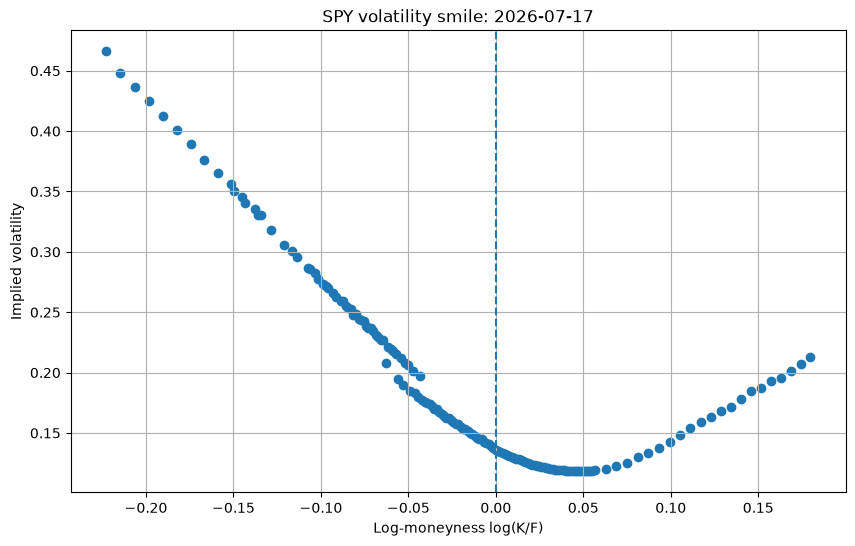

In [105]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls_near_money["log_moneyness"],
    calls_near_money["impliedVolatility"]
)
plt.axvline(0, linestyle="--")
plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Implied volatility")
plt.title(f"SPY volatility smile: {expiration}")
plt.grid()
plt.show()

In [106]:
from scipy.stats import norm
from scipy.optimize import brentq
import math

In [107]:
today = pd.Timestamp.now().normalize()
expiration_date = pd.Timestamp(expiration)

days_to_expiration = (expiration_date - today).days
T = days_to_expiration / 365

print("Days to expiration:", days_to_expiration)
print("T:", T)

Days to expiration: 32
T: 0.08767123287671233


In [108]:
r = 0.04

forward_price = spot_price * np.exp(r * T)

print("Spot:", spot_price)
print("Forward:", forward_price)

Spot: 756.0800170898438
Forward: 758.7361303523288


In [109]:
def black_call_price(F, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        return np.nan

    d1 = (
        np.log(F / K)
        + 0.5 * sigma**2 * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call_price = np.exp(-r * T) * (
        F * norm.cdf(d1)
        - K * norm.cdf(d2)
    )

    return call_price

In [110]:
test_price = black_call_price(
    F=forward_price,
    K=spot_price,
    T=T,
    r=r,
    sigma=0.20
)

print("Call price with 20% volatility:", test_price)

Call price with 20% volatility: 19.18303839413093


In [111]:
def calculate_implied_volatility(
    market_price,
    F,
    K,
    T,
    r
):
    def difference(sigma):
        model_price = black_call_price(
            F=F,
            K=K,
            T=T,
            r=r,
            sigma=sigma
        )

        return model_price - market_price

    try:
        implied_vol = brentq(
            difference,
            0.0001,
            5.0
        )

        return implied_vol

    except ValueError:
        return np.nan

In [112]:
atm_index = (
    calls["strike"] - spot_price
).abs().idxmin()

test_option = calls.loc[atm_index]



In [113]:
my_iv = calculate_implied_volatility(
    market_price=test_option["mid_price"],
    F=forward_price,
    K=test_option["strike"],
    T=T,
    r=r
)

print("My implied volatility:", my_iv)
print(
    "Yahoo implied volatility:",
    test_option["impliedVolatility"]
)

My implied volatility: 0.12280778979390608
Yahoo implied volatility: 0.13608652008056643


In [114]:
calls["my_implied_volatility"] = calls.apply(
    lambda row: calculate_implied_volatility(
        market_price=row["mid_price"],
        F=forward_price,
        K=row["strike"],
        T=T,
        r=r
    ),
    axis=1
)

In [115]:
calls = calls.dropna(
    subset=["my_implied_volatility"]
)

In [116]:
calls[
    [
        "strike",
        "mid_price",
        "impliedVolatility",
        "my_implied_volatility"
    ]
].head(10)

,strike,mid_price,impliedVolatility,my_implied_volatility
78,696.0,62.530,0.252998,0.101856
80,698.0,60.630,0.248543,0.124132
81,699.0,59.560,0.244453,0.106342
82,700.0,58.865,0.243172,0.142802
83,701.0,57.785,0.242653,0.134234
84,702.0,56.750,0.238960,0.128792
85,703.0,55.790,0.236610,0.129962
86,704.0,54.980,0.237099,0.140668
87,705.0,54.020,0.234505,0.140526
88,706.0,53.010,0.231148,0.137553


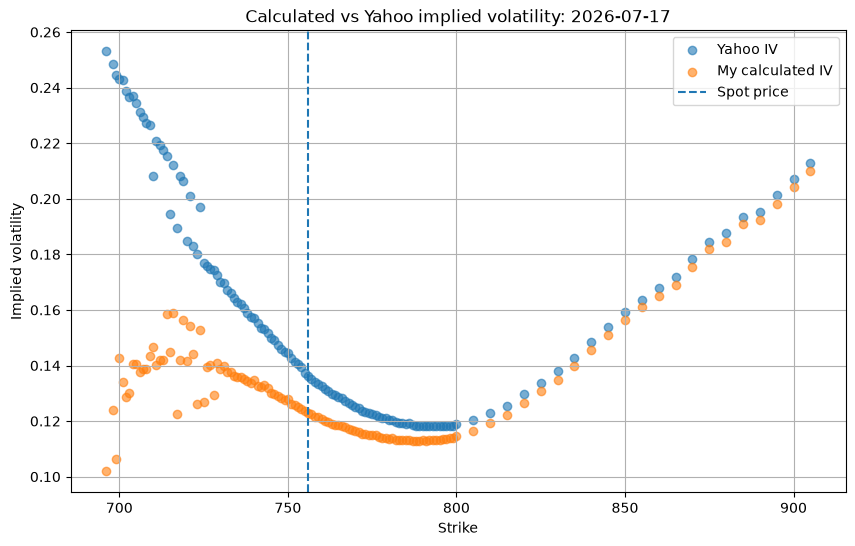

In [117]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls["strike"],
    calls["impliedVolatility"],
    label="Yahoo IV",
    alpha=0.6
)

plt.scatter(
    calls["strike"],
    calls["my_implied_volatility"],
    label="My calculated IV",
    alpha=0.6
)

plt.axvline(
    spot_price,
    linestyle="--",
    label="Spot price"
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(
    f"Calculated vs Yahoo implied volatility: {expiration}"
)

plt.legend()
plt.grid()
plt.show()

In [118]:
option_chain = ticker.option_chain(expiration)

calls = option_chain.calls.copy()
puts = option_chain.puts.copy()

In [119]:
def clean_options(options):
    options = options.copy()

    options = options[
        (options["bid"] > 0) &
        (options["ask"] > options["bid"])
    ].copy()

    options["mid_price"] = (
        options["bid"] + options["ask"]
    ) / 2

    options["relative_spread"] = (
        options["ask"] - options["bid"]
    ) / options["mid_price"]

    options = options[
        options["relative_spread"] < 0.30
    ].copy()

    options = options[
        options["openInterest"] > 0
    ].copy()

    return options

In [120]:
calls = clean_options(calls)
puts = clean_options(puts)

In [121]:
call_put_pairs = calls[
    ["strike", "mid_price", "relative_spread"]
].merge(
    puts[
        ["strike", "mid_price", "relative_spread"]
    ],
    on="strike",
    suffixes=("_call", "_put")
)

In [122]:
call_put_pairs.head()

,strike,mid_price_call,relative_spread_call,mid_price_put,relative_spread_put
0,420.0,335.700,0.009413,0.035,0.285714
1,425.0,330.710,0.009555,0.045,0.222222
2,430.0,309.635,0.009075,0.045,0.222222
3,435.0,320.975,0.010935,0.045,0.222222
4,440.0,315.725,0.009977,0.055,0.181818


In [123]:
call_put_pairs["forward_candidate"] = (
    call_put_pairs["strike"]
    + np.exp(r * T) * (
        call_put_pairs["mid_price_call"]
        - call_put_pairs["mid_price_put"]
    )
)

In [124]:
call_put_pairs[
    [
        "strike",
        "mid_price_call",
        "mid_price_put",
        "forward_candidate"
    ]
].head(20)

,strike,mid_price_call,mid_price_put,forward_candidate
0,420.0,335.700,0.035,756.844193
1,425.0,330.710,0.045,756.826628
2,430.0,309.635,0.045,740.677591
3,435.0,320.975,0.045,757.057429
4,440.0,315.725,0.055,756.778950
5,450.0,305.840,0.055,756.859224
6,460.0,295.825,0.065,756.799007
7,465.0,290.990,0.065,756.947021
8,470.0,285.830,0.075,756.758859
9,475.0,281.025,0.085,756.926944


In [127]:
near_atm_pairs = call_put_pairs[
    call_put_pairs["strike"].between(
        0.90 * spot_price,
        1.10 * spot_price
    )
].copy()

In [128]:
near_atm_pairs["pair_spread"] = (
    near_atm_pairs["relative_spread_call"]
    + near_atm_pairs["relative_spread_put"]
)

best_pairs = near_atm_pairs.nsmallest(
    max(3, len(near_atm_pairs) // 2),
    "pair_spread"
)

best_pairs

,strike,mid_price_call,relative_spread_call,mid_price_put,relative_spread_put,forward_candidate,pair_spread
128,758.0,11.335,0.000882,12.430,0.003218,756.901153,0.004100
126,756.0,12.505,0.002399,11.620,0.003442,756.888109,0.005841
127,757.0,11.855,0.002531,12.020,0.003328,756.834420,0.005858
129,759.0,10.755,0.002789,12.970,0.003084,756.777219,0.005873
125,755.0,13.015,0.002305,11.150,0.003587,756.871552,0.005892
124,754.0,13.625,0.002202,10.770,0.003714,756.865030,0.005916
130,760.0,10.225,0.002934,13.385,0.003736,756.828899,0.006670
115,745.0,19.665,0.007628,7.765,0.003863,756.941805,0.011491
120,750.0,16.235,0.008007,9.270,0.004315,756.989468,0.012322
117,747.0,18.240,0.008772,8.300,0.004819,756.974919,0.013591


In [129]:
forward_price = best_pairs[
    "forward_candidate"
].median()

print("Spot price:", spot_price)
print("Market-implied forward:", forward_price)

Spot price: 756.0800170898438
Market-implied forward: 756.9576097403567


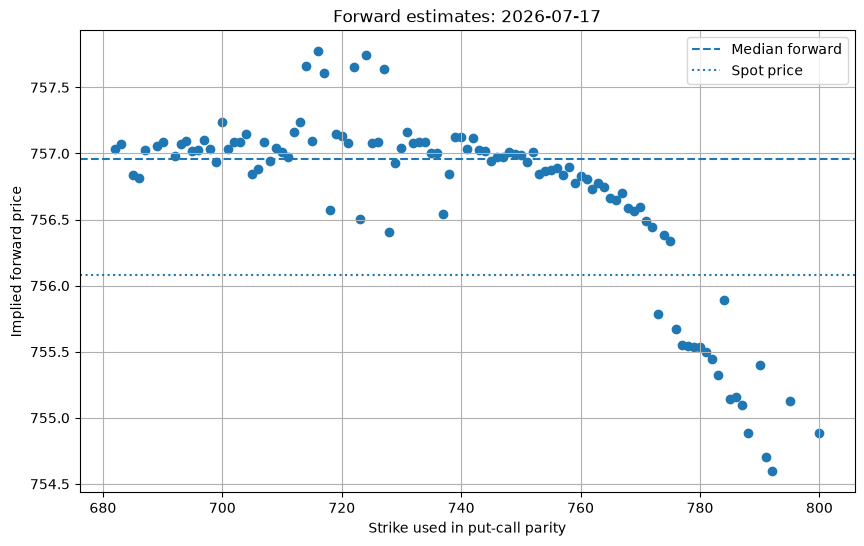

In [130]:
plt.figure(figsize=(10, 6))

plt.scatter(
    near_atm_pairs["strike"],
    near_atm_pairs["forward_candidate"]
)

plt.axhline(
    forward_price,
    linestyle="--",
    label="Median forward"
)

plt.axhline(
    spot_price,
    linestyle=":",
    label="Spot price"
)

plt.xlabel("Strike used in put-call parity")
plt.ylabel("Implied forward price")
plt.title(f"Forward estimates: {expiration}")
plt.legend()
plt.grid()
plt.show()

In [131]:
def black_put_price(F, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        return np.nan

    d1 = (
        np.log(F / K)
        + 0.5 * sigma**2 * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    put_price = np.exp(-r * T) * (
        K * norm.cdf(-d2)
        - F * norm.cdf(-d1)
    )

    return put_price

In [132]:
def calculate_implied_volatility_upd(
    market_price,
    F,
    K,
    T,
    r,
    option_type
):
    def difference(sigma):

        if option_type == "call":
            model_price = black_call_price(
                F=F,
                K=K,
                T=T,
                r=r,
                sigma=sigma
            )

        elif option_type == "put":
            model_price = black_put_price(
                F=F,
                K=K,
                T=T,
                r=r,
                sigma=sigma
            )

        else:
            raise ValueError(
                "option_type must be call or put"
            )

        return model_price - market_price

    try:
        return brentq(
            difference,
            0.0001,
            5.0
        )

    except ValueError:
        return np.nan

In [133]:
otm_puts = puts[
    puts["strike"] < forward_price
].copy()

In [134]:
otm_calls = calls[
    calls["strike"] >= forward_price
].copy()

In [135]:
otm_puts["my_implied_volatility"] = otm_puts.apply(
    lambda row: calculate_implied_volatility_upd(
        market_price=row["mid_price"],
        F=forward_price,
        K=row["strike"],
        T=T,
        r=r,
        option_type="put"
    ),
    axis=1
)

In [136]:
otm_puts["option_type"] = "put"

In [137]:
otm_calls["my_implied_volatility"] = otm_calls.apply(
    lambda row: calculate_implied_volatility_upd(
        market_price=row["mid_price"],
        F=forward_price,
        K=row["strike"],
        T=T,
        r=r,
        option_type="call"
    ),
    axis=1
)

In [138]:
otm_calls["option_type"] = "call"

In [139]:
smile_data = pd.concat(
    [
        otm_puts,
        otm_calls
    ],
    ignore_index=True
)

In [140]:
smile_data = smile_data.dropna(
    subset=["my_implied_volatility"]
)

In [141]:
smile_data = smile_data[
    smile_data["my_implied_volatility"].between(
        0.01,
        2.0
    )
].copy()

In [142]:
smile_data = smile_data.sort_values("strike")

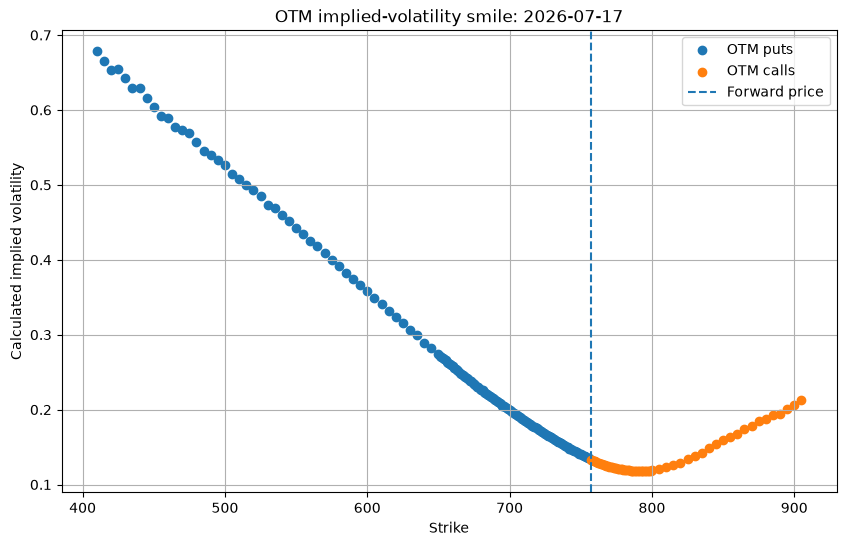

In [143]:
plt.figure(figsize=(10, 6))

put_data = smile_data[
    smile_data["option_type"] == "put"
]

call_data = smile_data[
    smile_data["option_type"] == "call"
]

plt.scatter(
    put_data["strike"],
    put_data["my_implied_volatility"],
    label="OTM puts"
)

plt.scatter(
    call_data["strike"],
    call_data["my_implied_volatility"],
    label="OTM calls"
)

plt.axvline(
    forward_price,
    linestyle="--",
    label="Forward price"
)

plt.xlabel("Strike")
plt.ylabel("Calculated implied volatility")
plt.title(
    f"OTM implied-volatility smile: {expiration}"
)
plt.legend()
plt.grid()
plt.show()

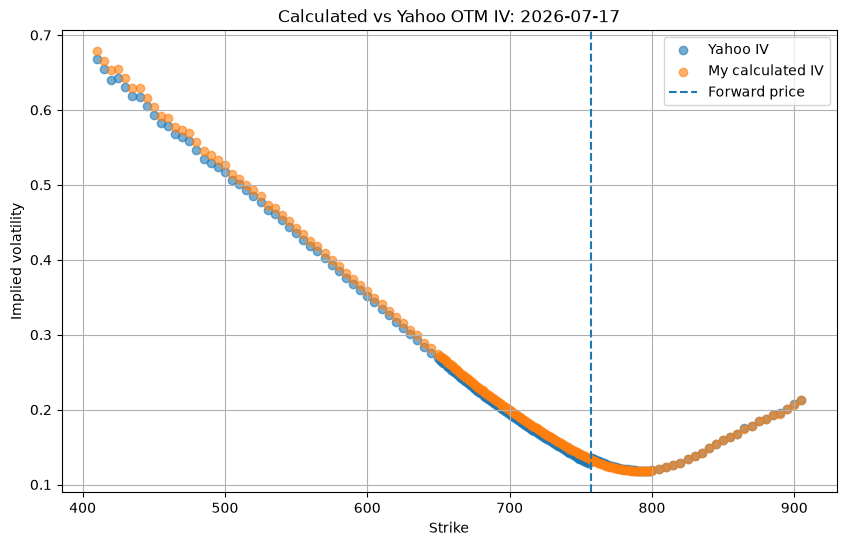

In [144]:
plt.figure(figsize=(10, 6))

plt.scatter(
    smile_data["strike"],
    smile_data["impliedVolatility"],
    label="Yahoo IV",
    alpha=0.6
)

plt.scatter(
    smile_data["strike"],
    smile_data["my_implied_volatility"],
    label="My calculated IV",
    alpha=0.6
)

plt.axvline(
    forward_price,
    linestyle="--",
    label="Forward price"
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(
    f"Calculated vs Yahoo OTM IV: {expiration}"
)
plt.legend()
plt.grid()
plt.show()